# Local Outlier Factor

This script uses the unified_dataset.csv by converting feature text to numbers, standard scaling data, and the fraud_flag to perform local outlier factor analysis. 

In [1]:
!pip install --upgrade scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv("/dsa/groups/casestudycf25/team02/unified_dataset.csv")

In [4]:
# Remove NAs
%matplotlib inline

subset=data.iloc[:, 0:len(data.columns)].copy()

display(subset[subset.isna().any(axis=1)])

,npi,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,avg_suplr_sbmtd_chrg_sum,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,...,physician_covered_recipient,year_leie,excltype,num_exclusions_alltime,num_exclusion_types_alltime,fraud_flag,Rfrg_NPI,specialty_type,specialty_lvl1,specialty
0,1003000126,2021,0,129.776563,41.940392,31.813932,34.260562,519.106250,167.761567,127.255730,...,NaN,NaN,NaN,NaN,NaN,0,1003000126,Medical Doctor,Allopathic & Osteopathic Physicians,Hospitalist
1,1003000126,2022,0,209.273634,54.750832,41.764741,52.602407,418.547268,109.501664,83.529481,...,NaN,NaN,NaN,NaN,NaN,0,1003000126,Medical Doctor,Allopathic & Osteopathic Physicians,Hospitalist
2,1003000126,2023,0,152.346111,48.740210,32.699442,42.116461,457.038333,146.220631,98.098326,...,NaN,NaN,NaN,NaN,NaN,0,1003000126,Medical Doctor,Allopathic & Osteopathic Physicians,Hospitalist
3,1003000480,2021,0,272.003846,80.513846,64.407692,84.701538,272.003846,80.513846,64.407692,...,0.0,NaN,NaN,NaN,NaN,0,1003000480,Medical Doctor,Allopathic & Osteopathic Physicians,General Surgery
4,1003000522,2021,0,133.101129,22.805968,18.243952,19.471129,266.202258,45.611935,36.487903,...,NaN,NaN,NaN,NaN,NaN,0,1003000522,Doctor of Osteopathy,Allopathic & Osteopathic Physicians,Family Practice
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873533,1992999122,2023,0,131.440754,45.271515,34.787840,36.480178,1445.848292,497.986665,382.666242,...,0.0,NaN,NaN,NaN,NaN,0,1992999122,Medical Doctor,Allopathic & Osteopathic Physicians,Internal Medicine
873534,1992999551,2021,0,196.827930,33.849452,25.531641,32.578168,1574.623440,270.795620,204.253124,...,0.0,NaN,NaN,NaN,NaN,0,1992999551,Medical Doctor,Allopathic & Osteopathic Physicians,Internal Medicine
873535,1992999551,2022,0,66.296193,23.048309,17.713123,21.564191,397.777161,138.289853,106.278738,...,NaN,NaN,NaN,NaN,NaN,0,1992999551,Medical Doctor,Allopathic & Osteopathic Physicians,Internal Medicine
873536,1992999551,2023,0,162.403127,62.296425,46.640118,54.865182,1461.628145,560.667821,419.761064,...,0.0,NaN,NaN,NaN,NaN,0,1992999551,Medical Doctor,Allopathic & Osteopathic Physicians,Internal Medicine


### Prep the Data

In [5]:
# Remove all columns whose name contains "date" (case-insensitive)
cols_to_drop = [col for col in subset.columns if 'date' in col.lower()]
subset = subset.drop(columns=cols_to_drop)

In [6]:
subset.dropna(subset = ["n_records"] , inplace = True)

In [7]:
subset.shape

(241269, 167)

In [8]:
subset["num_exclusions_alltime"] = (
      subset["num_exclusions_alltime"]
      .fillna(-1)       # turn NaN into 0
      .astype('int8')
)

In [9]:
subset["num_exclusion_types_alltime"] = (
      subset["num_exclusion_types_alltime"]
      .fillna(-1)       # turn NaN into 0
      .astype('int8')
)

In [10]:
subset.drop(columns = ["Rfrg_NPI", "npi", "covered_recipient_npi", "target", "year_leie"], inplace = True)

In [11]:
drop_cols = [c for c in subset.columns if c.endswith("_median") or c.endswith("_min") or c.endswith("_max")]  

# Drop those columns from the dataframe;
subset = subset.drop(columns=drop_cols)  

In [12]:
# subset.dropna(inplace = True)

In [13]:
subset.shape

(241269, 138)

In [14]:
subset["excltype"].unique()

array([nan, '1128a1', '1128a2', '1128a3', '1128b7'], dtype=object)

In [15]:
########################
# Mapping Text columns to numbers
#############################
excltype_mapping = {'1128a1': 1, '1128a2': 2, '1128a3': 3,'1128b7':7}

In [16]:
subset["excltype"] = (
      subset["excltype"]
      .map(excltype_mapping)     # map Yes/No
      .fillna(0)       # turn NaN into 0
      .astype('int8')
)

In [17]:
# Calculate NaN percentage per column
nan_percent = subset.isna().mean() * 100  # or df.isnull().mean() * 100

# Filter to only columns with NaN % > 0
nan_percent = nan_percent[nan_percent > 0]

# Sort (optional)
nan_percent = nan_percent.sort_values(ascending=False)

print(nan_percent)

avg_suplr_sbmtd_chrg_std        21.974642
avg_suplr_mdcr_alowd_amt_std    21.974642
avg_suplr_mdcr_pymt_amt_std     21.974642
avg_suplr_mdcr_stdzd_amt_std    21.974642
tot_suplrs_std                  21.974642
tot_suplr_benes_std             21.974642
tot_suplr_clms_std              21.974642
tot_suplr_srvcs_std             21.974642
dtype: float64


In [18]:
subset.drop(columns = nan_percent.index, inplace = True)

In [19]:
# X = all columns except 'fraud_flag'
X = subset.drop(columns=['fraud_flag']).select_dtypes(include='number')

# y = target column
y = subset['fraud_flag']

In [20]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
X_scaled.shape

(241269, 126)

## LOF Grid Search

In [22]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import ParameterGrid

In [23]:
# Sample rows
n_sample = 24_000
idx = np.random.choice(X_scaled.shape[0], size=n_sample, replace=False)
X_small = X_scaled[idx]

In [24]:
param_grid = {
    "n_neighbors": [10, 20, 35, 50],
    "contamination": [0.005, 0.01, 0.05, 0.1],
    "metric": ["minkowski"],
    "leaf_size": [10, 30, 40 ]
}

grid = list(ParameterGrid(param_grid))

results = []

for params in grid:
    lof = LocalOutlierFactor(
        n_neighbors=params["n_neighbors"],
        contamination=params["contamination"],
        metric=params["metric"],
        leaf_size=params["leaf_size"],
        novelty=False  # classic LOF, only detects on the training set
    )
    
    # fit_predict returns 1 for inliers, -1 for outliers
    labels = lof.fit_predict(X_small)
    scores = -lof.negative_outlier_factor_  # larger = more anomalous
    
    inlier_scores = scores[labels == 1]
    outlier_scores = scores[labels == -1]
    
    # skip degenerate cases (no outliers found)
    if len(outlier_scores) == 0 or len(inlier_scores) == 0:
        continue
    
    # Simple separation metric: (mean_outliers - mean_inliers) / std_all
    separation = (outlier_scores.mean() - inlier_scores.mean()) / scores.std()
    
    results.append({
        **params,
        "separation": separation,
        "n_outliers": len(outlier_scores)
    })

# Put in a dataframe to inspect
results_df = pd.DataFrame(results).sort_values("separation", ascending=False)
print(results_df.head())


    contamination  leaf_size     metric  n_neighbors  separation  n_outliers
3           0.005         10  minkowski           50    4.872326         120
7           0.005         30  minkowski           50    4.872326         120
11          0.005         40  minkowski           50    4.872326         120
10          0.005         40  minkowski           35    4.324845         120
2           0.005         10  minkowski           35    4.324845         120


### Best Parameters

Return the best parameters

In [25]:
best = results_df.iloc[0].to_dict()
print("Best parameters:", best)

best_params = {
    "n_neighbors": int(best["n_neighbors"]),
    "contamination": float(best["contamination"]),
    "metric": best["metric"],
    "leaf_size": int(best["leaf_size"])
}

lof_best = LocalOutlierFactor(
    **best_params,
    novelty=False
)
labels_best = lof_best.fit_predict(X_small)
scores_best = -lof_best.negative_outlier_factor_


Best parameters: {'contamination': 0.005, 'leaf_size': 10, 'metric': 'minkowski', 'n_neighbors': 50, 'separation': 4.87232592281622, 'n_outliers': 120}


### Visualize Local Outlier Factor

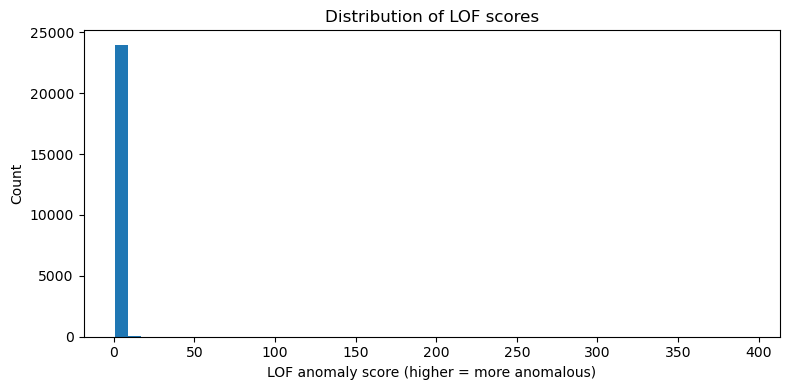

In [26]:
plt.figure(figsize=(8, 4))
plt.hist(scores_best, bins=50)
plt.xlabel("LOF anomaly score (higher = more anomalous)")
plt.ylabel("Count")
plt.title("Distribution of LOF scores")
plt.tight_layout()
plt.show()

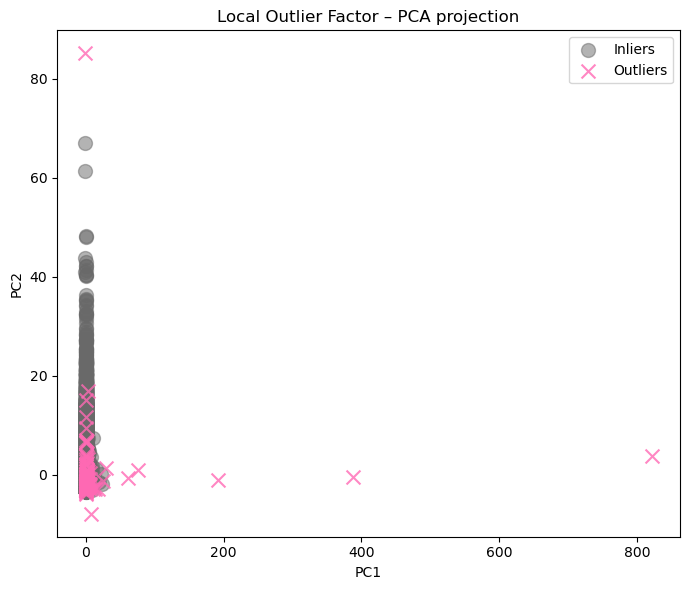

In [27]:
# Project to 2D for visualization only
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_small)

inliers = labels_best == 1
outliers = labels_best == -1

plt.figure(figsize=(7, 6))
plt.scatter(
    X_2d[inliers, 0], X_2d[inliers, 1],
    s=100, alpha=0.5, label="Inliers",
    color="dimgray"        # dark grey
)
plt.scatter(
    X_2d[outliers, 0], X_2d[outliers, 1],
    s=100, alpha=0.8, marker="x", label="Outliers",
    color="#ff69b4"        # pink
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Local Outlier Factor – PCA projection")
plt.legend()
plt.tight_layout()
plt.show()

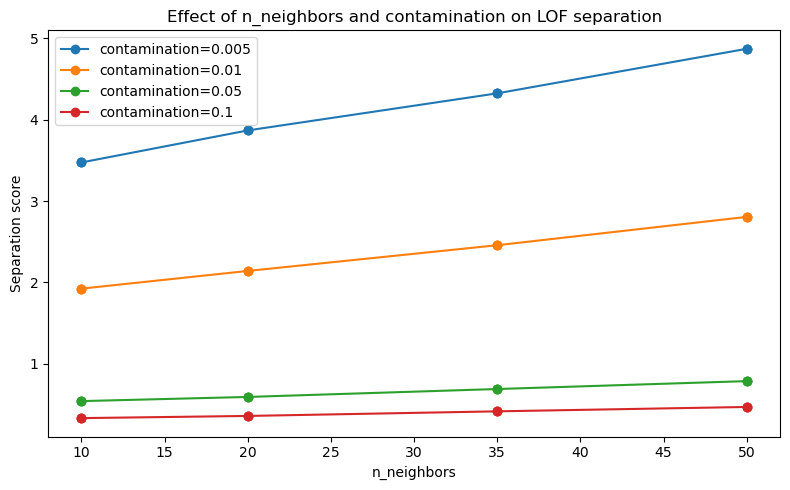

In [28]:
# plot separation vs n_neighbors for each contamination
plt.figure(figsize=(8, 5))

for cont in sorted(results_df["contamination"].unique()):
    subset = results_df[results_df["contamination"] == cont]
    subset = subset.sort_values("n_neighbors")
    plt.plot(
        subset["n_neighbors"],
        subset["separation"],
        marker="o",
        label=f"contamination={cont}"
    )

plt.xlabel("n_neighbors")
plt.ylabel("Separation score")
plt.title("Effect of n_neighbors and contamination on LOF separation")
plt.legend()
plt.tight_layout()
plt.show()